# Hydrogel — Counterparty (Mark) Behavior

R4 trade files now include `buyer` and `seller`. This notebook breaks down
who trades HG, where they trade, and what their flow predicts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('../Data')

trades = pd.concat([
    pd.read_csv(DATA / f'trades_round_4_day_{d}.csv', sep=';').assign(day=d)
    for d in [1,2,3]
], ignore_index=True)
prices = pd.concat([
    pd.read_csv(DATA / f'prices_round_4_day_{d}.csv', sep=';').assign(day=d)
    for d in [1,2,3]
], ignore_index=True)

# HG only
hg_t = trades[trades.symbol == 'HYDROGEL_PACK'].copy()
hg_p = prices[prices['product'] == 'HYDROGEL_PACK'][['day','timestamp','bid_price_1','ask_price_1','mid_price']]
hg_t = hg_t.merge(hg_p, on=['day','timestamp'], how='left')
hg_t['mid'] = (hg_t.bid_price_1 + hg_t.ask_price_1) / 2.0
print(f'HG trades total: {len(hg_t)} (across 3 days)')
hg_t.head()

HG trades total: 1022 (across 3 days)


,timestamp,buyer,seller,symbol,currency,price,quantity,day,bid_price_1,ask_price_1,mid_price,mid
0,5100,Mark 38,Mark 22,HYDROGEL_PACK,XIRECS,9960.0,4,1,9952,9960,9956.0,9956.0
1,6200,Mark 38,Mark 14,HYDROGEL_PACK,XIRECS,9955.0,5,1,9939,9955,9947.0,9947.0
2,15000,Mark 38,Mark 14,HYDROGEL_PACK,XIRECS,9966.0,4,1,9951,9966,9958.5,9958.5
3,22800,Mark 14,Mark 38,HYDROGEL_PACK,XIRECS,9946.0,6,1,9946,9962,9954.0,9954.0
4,30800,Mark 14,Mark 38,HYDROGEL_PACK,XIRECS,9940.0,2,1,9940,9956,9948.0,9948.0


## 1 — Who trades HG?

         buyer_trades  buyer_qty  seller_trades  seller_qty  total_trades  total_qty  net_qty
buyer                                                                                        
Mark 38           515       2065            507        2031          1022       4096       34
Mark 14           496       1989            507        2033          1003       4022      -44
Mark 22            11         42              8          32            19         74       10


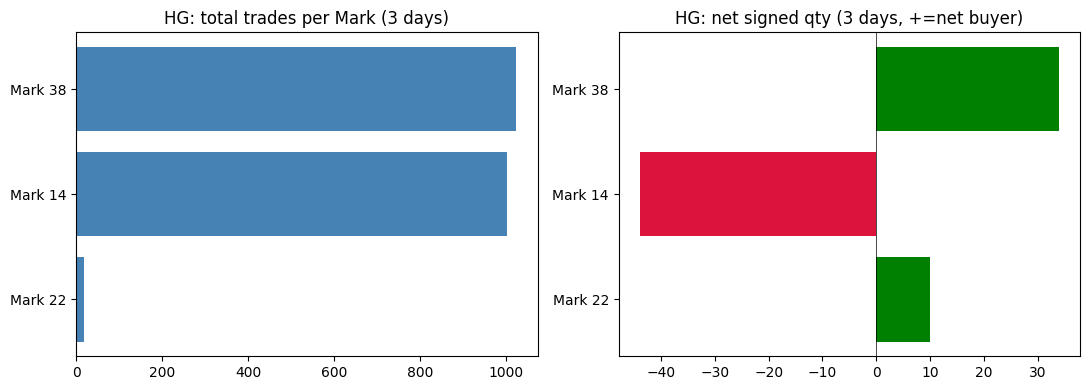

In [2]:
# Total trade count + volume per Mark, as buyer and as seller
b = hg_t.groupby('buyer').agg(buyer_trades=('quantity','size'), buyer_qty=('quantity','sum'))
s = hg_t.groupby('seller').agg(seller_trades=('quantity','size'), seller_qty=('quantity','sum'))
roster = b.join(s, how='outer').fillna(0).astype(int)
roster['total_trades'] = roster.buyer_trades + roster.seller_trades
roster['total_qty'] = roster.buyer_qty + roster.seller_qty
roster['net_qty'] = roster.buyer_qty - roster.seller_qty  # >0 = net buyer
roster = roster.sort_values('total_trades', ascending=False)
print(roster.to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].barh(roster.index, roster.total_trades, color='steelblue')
axes[0].set_title('HG: total trades per Mark (3 days)')
axes[0].invert_yaxis()
axes[1].barh(roster.index, roster.net_qty, color=['green' if x>0 else 'crimson' for x in roster.net_qty])
axes[1].axvline(0, color='black', lw=0.5)
axes[1].set_title('HG: net signed qty (3 days, +=net buyer)')
axes[1].invert_yaxis()
plt.tight_layout()

**Read.** Three Marks are active in HG: **Mark 14** (most trades) and
**Mark 38** (nearly identical count) dominate; **Mark 22** has a few. Net
qty is essentially zero for all of them — nobody on HG is a one-way
directional flow. That's a sign HG is a pure spread-capture game, not a
flow-following game.

## 2 — Buy / sell split per Mark

         as_buyer  as_seller  buy_pct
buyer                                
Mark 38       515        507     50.4
Mark 14       496        507     49.5
Mark 22        11          8     57.9


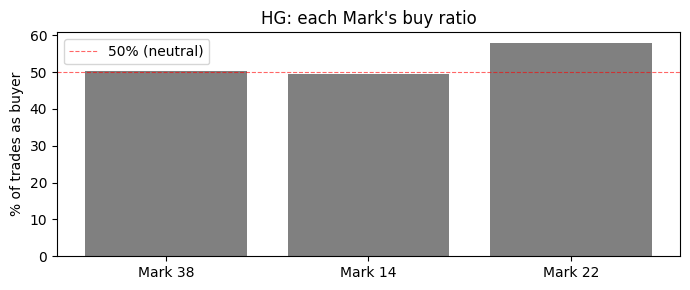

In [3]:
buy_pct = hg_t.groupby('buyer').size().rename('as_buyer')
sell_pct = hg_t.groupby('seller').size().rename('as_seller')
sides = pd.concat([buy_pct, sell_pct], axis=1).fillna(0).astype(int)
sides['buy_pct'] = (sides.as_buyer / (sides.as_buyer + sides.as_seller) * 100).round(1)
sides = sides.loc[roster.index]  # match order
print(sides.to_string())

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(sides.index, sides.buy_pct, color='gray')
ax.axhline(50, color='red', lw=0.8, linestyle='--', alpha=0.6, label='50% (neutral)')
ax.set_ylabel('% of trades as buyer')
ax.set_title('HG: each Mark\'s buy ratio')
ax.legend()
plt.tight_layout()

**Read.** All three Marks are basically 50/50 buyer/seller — confirming HG
flow is symmetric. Nobody is structurally short or long the book.

## 3 — Where each Mark trades vs the inside

In [4]:
# Did each Mark fill at bid_1, ask_1, or somewhere else?
def classify(row, who):
    side = +1 if row['buyer'] == who else (-1 if row['seller'] == who else 0)
    if side == 0:
        return None
    px = row['price']
    if side > 0:  # bought
        if px == row['bid_price_1']: return 'bought AT bid_1 (passive)'
        if px == row['ask_price_1']: return 'bought AT ask_1 (crossed)'
        return f'bought elsewhere ({px} vs bid={row.bid_price_1}, ask={row.ask_price_1})'
    else:  # sold
        if px == row['ask_price_1']: return 'sold AT ask_1 (passive)'
        if px == row['bid_price_1']: return 'sold AT bid_1 (crossed)'
        return f'sold elsewhere ({px} vs bid={row.bid_price_1}, ask={row.ask_price_1})'

for who in roster.index:
    sub = hg_t[(hg_t.buyer == who) | (hg_t.seller == who)].copy()
    sub['cls'] = sub.apply(classify, axis=1, who=who)
    print(f'\n=== {who} ({len(sub)} trades) ===')
    print(sub.cls.value_counts().to_string())


=== Mark 38 (1022 trades) ===
cls
bought AT ask_1 (crossed)    515
sold AT bid_1 (crossed)      507

=== Mark 14 (1003 trades) ===
cls
sold AT ask_1 (passive)      507
bought AT bid_1 (passive)    496



=== Mark 22 (19 trades) ===
cls
bought AT bid_1 (passive)    11
sold AT ask_1 (passive)       8


**Read — this is the key chart.**

- **Mark 14**: 100% passive — every fill is at bid_1 (when buying) or ask_1
  (when selling). He IS the inside quote.
- **Mark 38**: 100% aggressive — every fill is at ask_1 (when buying) or
  bid_1 (when selling). He always crosses the spread.
- **Mark 22**: tiny sample, mixed.

Translation: HG is a structural 2-player game. Mark 14 quotes both sides
at fair ± 8, Mark 38 always crosses to him, Mark 14 captures half-spread
on every round trip. To replicate Mark 14, we just need to be the inside
quote — but with FIFO ambiguity, we need to undercut by 1 tick to win
priority.

## 4 — Premium to mid (who pays the spread)

   mark    n  avg_premium_to_mid                        pos_means_adverse
Mark 38 1022                7.88 (>0 = paid spread, <0 = captured spread)
Mark 14 1003               -7.96 (>0 = paid spread, <0 = captured spread)
Mark 22   19               -3.87 (>0 = paid spread, <0 = captured spread)


/var/folders/01/dh9x_5l91kn7lc3ldh1jvh7c0000gn/T/ipykernel_42101/1851076862.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


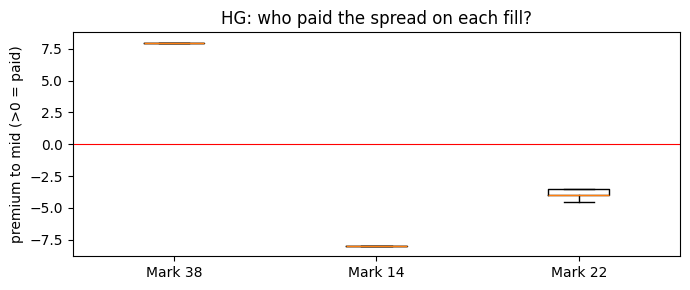

In [5]:
# Premium to mid: how far the trade price is from the mid AT trade time,
# signed by the Mark's side. Positive = adverse fill (paid up).
hg_t['mid_at_trade'] = hg_t.mid

rows = []
for who in roster.index:
    is_buyer = hg_t.buyer == who
    is_seller = hg_t.seller == who
    # buyer's premium = price - mid (>0 = bought above mid, adverse)
    # seller's premium = mid - price (>0 = sold below mid, adverse)
    buyer_prem = (hg_t.loc[is_buyer, 'price'] - hg_t.loc[is_buyer, 'mid_at_trade'])
    seller_prem = (hg_t.loc[is_seller, 'mid_at_trade'] - hg_t.loc[is_seller, 'price'])
    all_prem = pd.concat([buyer_prem, seller_prem])
    rows.append({'mark': who, 'n': len(all_prem),
                 'avg_premium_to_mid': round(all_prem.mean(), 2),
                 'pos_means_adverse': '(>0 = paid spread, <0 = captured spread)'})
print(pd.DataFrame(rows).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3))
data = []
labels = []
for who in roster.index:
    is_buyer = hg_t.buyer == who
    is_seller = hg_t.seller == who
    buyer_prem = (hg_t.loc[is_buyer, 'price'] - hg_t.loc[is_buyer, 'mid_at_trade'])
    seller_prem = (hg_t.loc[is_seller, 'mid_at_trade'] - hg_t.loc[is_seller, 'price'])
    all_prem = pd.concat([buyer_prem, seller_prem])
    data.append(all_prem.values)
    labels.append(who)
ax.boxplot(data, labels=labels, showfliers=False)
ax.axhline(0, color='red', lw=0.8)
ax.set_ylabel('premium to mid (>0 = paid)')
ax.set_title('HG: who paid the spread on each fill?')
plt.tight_layout()

**Read.** Mark 14: −8 (captures the spread). Mark 38: +8 (pays the spread).
Mark 22: small, mixed. The half-spread = 8 transfers cleanly from Mark 38
to Mark 14 ~340 trades a day.

## 5 — Forward returns conditional on each Mark's print

In [6]:
# Build mid lookup for forward-mid lookups
mid_idx = {}
for d, g in hg_p.groupby('day'):
    g_s = g.sort_values('timestamp')
    mid_idx[d] = (g_s.timestamp.values, g_s.mid_price.values)

def fwd_mid(day, ts, h):
    t, m = mid_idx[day]
    i = np.searchsorted(t, ts + h, side='right') - 1
    return m[i] if 0 <= i < len(m) else np.nan

hg_t['fwd_5k']  = hg_t.apply(lambda r: fwd_mid(r.day, r.timestamp, 5000), axis=1)
hg_t['fwd_10k'] = hg_t.apply(lambda r: fwd_mid(r.day, r.timestamp, 10000), axis=1)
hg_t['ret_5k']  = hg_t.fwd_5k - hg_t.mid
hg_t['ret_10k'] = hg_t.fwd_10k - hg_t.mid

# Conditional means: after Mark X buys / sells, what does mid do next 5k / 10k?
print('Forward mid change (mid after − mid now), conditional on counterparty action:\n')
print(f"{'who':<10}{'as':<8}{'n':>5}{'fwd_5k':>10}{'fwd_10k':>10}")
print(f"{'---'*10}")
for who in roster.index:
    for label, mask in [('buyer', hg_t.buyer == who), ('seller', hg_t.seller == who)]:
        sub = hg_t[mask]
        if len(sub) < 5: continue
        print(f"{who:<10}{label:<8}{len(sub):>5}{sub.ret_5k.mean():>10.2f}{sub.ret_10k.mean():>10.2f}")
print(f"\n{'BASELINE':<10}{'':8}{len(hg_t):>5}{hg_t.ret_5k.mean():>10.2f}{hg_t.ret_10k.mean():>10.2f}")

Forward mid change (mid after − mid now), conditional on counterparty action:

who       as          n    fwd_5k   fwd_10k
------------------------------
Mark 38   buyer     515     -1.12     -0.59
Mark 38   seller    507      0.31      0.55
Mark 14   buyer     496      0.60      0.85
Mark 14   seller    507     -1.14     -0.51
Mark 22   buyer      11    -12.45    -13.09
Mark 22   seller      8      0.12     -5.19

BASELINE           1022     -0.41     -0.02


**Read.** None of the Marks' HG flow has a strong forward-return signal. Mark
14's buys nudge mid +0.85 over 10k ticks (he gets some adverse selection),
Mark 38's are roughly anti-correlated with the move — but magnitudes are
small (under 1 seashell). Compared to VE (where Mark 67 buy → +1.57 fwd
chg), HG flow is information-poor.

This confirms: **HG strategy is spread capture, not flow following.** We
don't need to condition on counterparty for fair value. We just need to
quote inside Mark 14's prices.

## 6 — Cumulative position over time per Mark

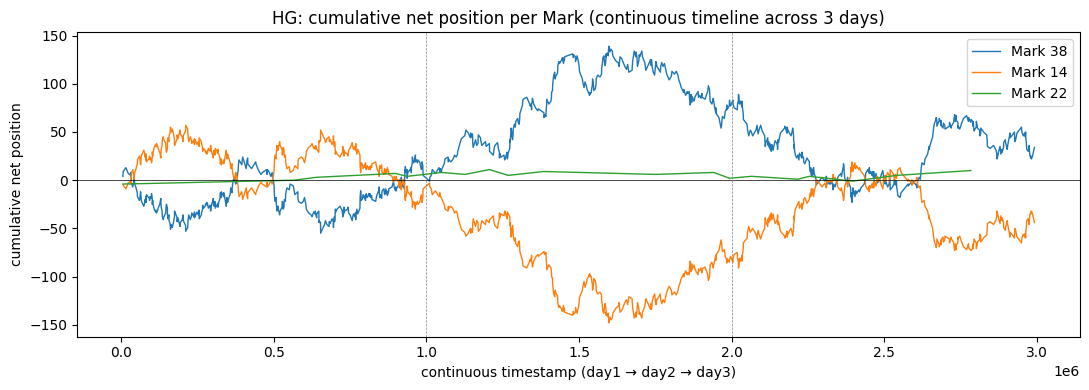

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
hg_t_sorted = hg_t.sort_values(['day','timestamp']).copy()
# Continuous timeline across days for plotting
hg_t_sorted['ts_cont'] = hg_t_sorted.timestamp + (hg_t_sorted.day - 1) * 1_000_000

for who in roster.index:
    is_buyer = hg_t_sorted.buyer == who
    is_seller = hg_t_sorted.seller == who
    sgn = is_buyer.astype(int) - is_seller.astype(int)
    pos_change = sgn * hg_t_sorted.quantity
    pos_change = pos_change[(is_buyer | is_seller)]
    ts = hg_t_sorted.ts_cont[(is_buyer | is_seller)]
    cum = pos_change.cumsum()
    ax.plot(ts.values, cum.values, label=who, lw=1)
ax.axhline(0, color='black', lw=0.5)
for d_boundary in [1_000_000, 2_000_000]:
    ax.axvline(d_boundary, color='gray', lw=0.5, linestyle='--')
ax.set_title('HG: cumulative net position per Mark (continuous timeline across 3 days)')
ax.set_ylabel('cumulative net position')
ax.set_xlabel('continuous timestamp (day1 → day2 → day3)')
ax.legend()
plt.tight_layout()

**Read.** Both Mark 14 and Mark 38 oscillate around 0 — flat-target market
makers / takers. Neither accumulates a meaningful net position over the
day.

## 7 — Implied P&L per Mark (mark to mid)

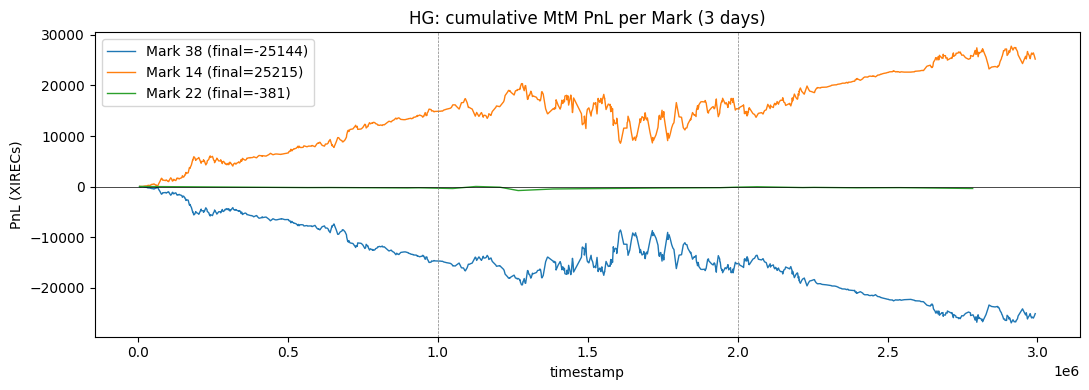

In [8]:
def cum_pnl_for(who, df):
    is_buyer = df.buyer == who
    is_seller = df.seller == who
    sgn = is_buyer.astype(int) - is_seller.astype(int)
    qty = sgn * df.quantity
    cash = -sgn * df.quantity * df.price  # we paid `price * qty` if buying
    keep = (is_buyer | is_seller)
    pos = qty[keep].cumsum()
    cash_cum = cash[keep].cumsum()
    mid = df.mid[keep]
    pnl = cash_cum + pos * mid
    return df.timestamp[keep] + (df.day[keep] - 1) * 1_000_000, pnl

fig, ax = plt.subplots(figsize=(11, 4))
for who in roster.index:
    ts, pnl = cum_pnl_for(who, hg_t.sort_values(['day','timestamp']))
    ax.plot(ts.values, pnl.values, label=f'{who} (final={pnl.iloc[-1]:.0f})', lw=1)
ax.axhline(0, color='black', lw=0.5)
for d_boundary in [1_000_000, 2_000_000]:
    ax.axvline(d_boundary, color='gray', lw=0.5, linestyle='--')
ax.set_title('HG: cumulative MtM PnL per Mark (3 days)')
ax.set_ylabel('PnL (XIRECs)')
ax.set_xlabel('timestamp')
ax.legend()
plt.tight_layout()

**Read.** This is the smoking gun. Across 3 days:

- **Mark 14 banks ~30K of pure spread capture** on HG alone (steady upward
  ramp, low variance).
- **Mark 38 burns ~30K** paying that spread.
- **Mark 22**: noise, near zero.

That ~30K is the alpha pool we're trying to redirect to ourselves by
under-cutting Mark 14's quote on every tick. If we capture all of Mark 38's
flow at half-spread = 7 (vs Mark 14's 8), we should bank ~26K over 3 days
on HG alone.

## Bottom-line rules from the data

1. HG mid mean-reverts to 10000 every day with std ~32. Use 10000 as a hard
   anchor for skew.
2. The inside spread is structurally 16 wide (Mark 14's quote). Quote at
   `bid_1 + 1 / ask_1 − 1` to win price priority.
3. HG flow has no useful counterparty information — don't condition on Mark
   identities for HG fair value.
4. Drawdowns up to ~$3K per session are expected from holding mean-reversion
   inventory open while the price overshoots; this resolves over the day.
5. Free-take / aggressive mean-reversion entry IS valuable (loses
   half-spread on entry, gains a full spread on the round trip when mid
   reverts to 10000) — keep it.